In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy.stats import linregress
import time
import os

In [22]:
def autocorrelation_fft(x, maxlag=None):
    """
    Compute the autocorrelation function using Fast Fourier Transform.
    
    This method is more efficient and numerically stable than direct computation,
    especially for long time series.
    
    Parameters
    ----------
    x : array-like
        Input time series data.
    maxlag : int, optional
        Maximum lag to compute. If None, uses len(x) - 1.
    
    Returns
    -------
    np.ndarray
        Normalized autocorrelation function from lag 0 to maxlag.
        ACF[k] = Cov(x[t], x[t+k]) / Var(x)
    
    Notes
    -----
    - Uses FFT convolution theorem: convolution in time = multiplication in frequency
    - Zero-pads to next power of 2 for optimal FFT performance
    - Returns 1.0 for all lags if variance is zero (constant series)
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if maxlag is None:
        maxlag = n - 1
    
    # Center the data by subtracting mean
    mean = x.mean()
    x = x - mean
    
    # Find next power of 2 for efficient FFT (zero-padding)
    m = 1 << (int(np.log2(2*n - 1)) + 1)
    
    # Compute autocorrelation via FFT: AC = IFFT(|FFT(x)|^2)
    fx = np.fft.rfft(x, n=m)
    acfull = np.fft.irfft(fx * np.conjugate(fx), n=m)[:n]
    acfull = acfull / n  # Normalize by length
    
    # Normalize by variance to get correlation
    var = x.var()
    if var == 0:
        return np.ones(maxlag+1)  # Constant series has ACF = 1 everywhere
    
    ac = acfull[:maxlag+1] / var
    return ac


def integrated_tau_from_ac(ac, c_factor=5, max_iter=200, tau=None):
    """
    Compute integrated autocorrelation time using self-consistent windowing.
    
    Implements Sokal's automatic windowing method where the integration window
    depends on the autocorrelation time itself, solved iteratively.
    
    Parameters
    ----------
    ac : np.ndarray
        Autocorrelation function values.
    c_factor : float, default 5
        Window multiplier: W = c_factor * tau. Typical values 3-6.
    max_iter : int, default 200
        Maximum iterations for convergence.
    tau : float, optional
        Initial guess for tau. If None, starts with 0.5.
    
    Returns
    -------
    float
        Integrated autocorrelation time τ_int.
        Returns np.inf if calculation fails.
    
    Notes
    -----
    Formula: τ_int = 1/2 + Σ(ACF[1:W])
    where W = c_factor * τ_int (solved self-consistently)
    
    Convergence: Iterates until |new_tau - tau| < 1e-6
    """
    if len(ac) < 2:
        return 0.5
    
    # Initialize tau with previous value or default
    if tau is None:
        tau = 0.5
    
    # Iterate to find self-consistent window
    for _ in range(max_iter):
        # Window size proportional to current tau estimate
        W = min(len(ac)-1, max(1, int(c_factor * tau)))
        
        # Compute new tau using current window
        new_tau = 0.5 + np.sum(ac[1:W+1])
        
        # Check validity
        if not np.isfinite(new_tau):
            return np.inf
        
        # Check convergence
        if abs(new_tau - tau) < 1e-6:
            return new_tau
        
        tau = new_tau
    
    return tau


def iterative_burn_and_tau(observable, c_factor=5, max_iter=10, min_fraction=0.001, verbose=False):
    """
    Automatically determine burn-in period and compute integrated autocorrelation time.
    
    Uses an iterative self-consistent approach:
    1. Estimate tau on current data
    2. Set burn-in = c_factor * tau
    3. Re-estimate tau on remaining data
    4. Repeat until burn-in stabilizes
    
    Parameters
    ----------
    observable : array-like
        Time series of observable (e.g., energy, magnetization).
    c_factor : float, default 3
        Multiplier for burn-in: burn = c_factor * tau.
        Also used for windowing in tau calculation.
    max_iter : int, default 10
        Maximum iterations for burn-in refinement.
    min_fraction : float, default 0.001
        Minimum fraction of data that must remain after burn-in (0.1%).
    verbose : bool, default False
        Print detailed iteration information.
    
    Returns
    -------
    burn : int
        Optimal burn-in index (number of initial points to discard).
    tau : float
        Integrated autocorrelation time of equilibrated data.
        Returns np.inf if estimation fails.
    ac : np.ndarray
        Final autocorrelation function of equilibrated data.
    
    Notes
    -----
    The algorithm handles three failure modes:
    1. Remaining series too short after burn-in
    2. Invalid tau (non-finite or non-positive)
    3. Burn-in exceeds total series length
    
    Final tau is more accurate than iteration values because:
    - Uses longer maxlag (up to 10M vs limited during iteration)
    - Computed on properly equilibrated data
    """
    n = len(observable)
    burn = 0  # Initial burn-in
    prev_burn = -1  # Previous iteration's burn-in
    tau = None  # Carries forward between iterations for faster convergence

    # Iteratively refine burn-in period
    for it in range(max_iter):
        # Extract data after current burn-in
        data = observable[burn:]
        
        # Check if enough data remains
        if len(data) < max(100, int(min_fraction * n)):
            if verbose:
                print(f"  [iter {it}] remaining series too short ({len(data)}), stopping.")
            break

        # Compute autocorrelation with limited maxlag for speed
        maxlag = min(len(data)-1, max(len(data)//10, 10000))
        ac = autocorrelation_fft(data, maxlag=maxlag)
        
        # Estimate tau (passes previous tau as initial guess)
        tau = integrated_tau_from_ac(ac, c_factor=c_factor, tau=tau)

        # Validate tau
        if not np.isfinite(tau) or tau <= 0:
            if verbose:
                print(f"  [iter {it}] invalid τ (tau={tau}), aborting iteration.")
            tau = np.inf
            break

        # Propose new burn-in based on tau
        new_burn = int(c_factor * tau)
        if verbose:
            print(f"  [iter {it}] len(data)={len(data)}, tau={tau:.3f}, new_burn={new_burn}")

        # Check if burn-in would exceed series length
        if new_burn >= len(observable):
            if verbose:
                print(f"  new_burn ({new_burn}) >= total series ({len(observable)}): abort.")
            burn = len(observable)
            tau = np.inf
            break

        # Check convergence: burn-in hasn't changed
        if new_burn == prev_burn:
            if verbose:
                print(f"  [convergence] burn-in stabilized at {burn}")
            burn = new_burn
            break

        # Update for next iteration
        prev_burn = new_burn
        burn = new_burn

    # Final validation: check if enough data remains
    data = observable[burn:]
    if len(data) < max(100, int(min_fraction * n)):
        if verbose:
            print(f"  Final: remaining series too short ({len(data)}). τ not computed.")
        return burn, np.inf, np.array([np.nan])

    # Final accurate computation with longer maxlag
    maxlag = len(data)//5
    ac = autocorrelation_fft(data, maxlag=maxlag)
    # Reset tau if it's infinity to avoid overflow in integrated_tau_from_ac
    tau_init = None if (tau is None or not np.isfinite(tau)) else tau
    tau = integrated_tau_from_ac(ac, c_factor=c_factor, tau=tau_init)

    return burn, tau, ac

In [5]:
base_dir = "data/Metropolis_Temp_Scan_3_Million_Sweeps"
beta_c = 0.4407
h = 0.0

L_list = []
for folder in os.listdir(base_dir):
    m = re.match(r"L_(\d+)", folder)
    if m:
        L_list.append(int(m.group(1)))
L_list = sorted(L_list)
print("Detected sizes:", L_list)


Detected sizes: [2, 4, 8, 16, 32, 64, 128]


In [6]:
# replace data for L=2 with 600,000 sweeps
print(L_list)

[2, 4, 8, 16, 32, 64, 128]


In [7]:
# Storage for results: tau_vs_L[0] = magnetization, tau_vs_L[1] = energy
tau_vs_L = [[], []]
skipped = []  # Track which L values couldn't be processed

start_all = time.time()

# Process each lattice size
for L in L_list:
    print(f"\n===== Processing L = {L} =====")
    
    # Construct file path for this lattice size
    file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"⚠️ Missing file: {file_path}")
        skipped.append((L, "missing file"))
        continue

    # Load simulation data
    data = np.load(file_path)
    
    # # Special case: use longer simulation (10M sweeps) for L=128
    # # This ensures sufficient statistics for the largest system size
    # if L == 128:
    #     alt_dir = "data/Metropolis_Temp_Scan_10_Million_Sweeps"
    #     alt_path = f"{alt_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    #     data = np.load(alt_path)

    # Analyze both magnetization (i=0) and energy (i=1)
    for i, obs in enumerate(["magnetizations", "energies"]):
        tau = None
        print(f"\n--- Analysis of '{obs}' ---")
        
        # Check if observable exists in data file
        if obs not in data:
            print(f"⚠️ Missing data '{obs}' in file: {file_path}")
            skipped.append((L, f"missing_{obs}"))
            continue

        # Extract time series
        mags_engs = data[obs]
        N = len(mags_engs)
        print(f"Series length = {N}")

        # Compute burn-in and autocorrelation time
        t0 = time.time()
        burn, tau, ac = iterative_burn_and_tau(mags_engs, c_factor=5, min_fraction=0.001, verbose=True)
        dt = time.time() - t0

        # Validate tau: must be finite and positive
        if not np.isfinite(tau):
            print(f"  → Invalid τ (tau={tau}). Skipping this size.")
            skipped.append((L, f"tau_bad_{tau}_for_{obs}"))
            continue

        # Check if series is long enough for reliable statistics
        # Rule of thumb: need at least 50*tau independent samples
        min_points_required = 50 * tau
        if N < min_points_required:
            print(f"  → Series too short for L={L} (N={N}, tau≈{tau:.1f}, required > {min_points_required:.0f})")
            skipped.append((L, f"series_too_short_for_{obs}"))
            continue

        # Success: save results
        print(f"Optimized burn-in: {burn}")
        print(f"Estimated τ_int = {tau:.4f}  (compute time: {dt:.1f}s)")
        tau_vs_L[i].append((L, tau))

total_time = time.time() - start_all
print(f"\nTotal runtime: {total_time:.1f}s")


===== Processing L = 2 =====

--- Analysis of 'magnetizations' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=4.070, new_burn=20
  [iter 1] len(data)=2999980, tau=4.070, new_burn=20
  [convergence] burn-in stabilized at 20
Optimized burn-in: 20
Estimated τ_int = 4.0700  (compute time: 2.6s)

--- Analysis of 'energies' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=0.449, new_burn=2
  [iter 1] len(data)=2999998, tau=0.449, new_burn=2
  [convergence] burn-in stabilized at 2
Optimized burn-in: 2
Estimated τ_int = 0.4489  (compute time: 3.2s)

===== Processing L = 4 =====

--- Analysis of 'magnetizations' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=19.273, new_burn=96
  [iter 1] len(data)=2999904, tau=19.274, new_burn=96
  [convergence] burn-in stabilized at 96
Optimized burn-in: 96
Estimated τ_int = 19.2738  (compute time: 3.0s)

--- Analysis of 'energies' ---
Series length = 3000000
  [iter 0] len(data)=3000000, tau=1.220, new_burn=6
  [it

In [8]:
print("\n=== Final size check ===")
print("Skipped L:", skipped)
print("L kept for fitting:", [l for l, _ in tau_vs_L[0]])





=== Final size check ===
Skipped L: []
L kept for fitting: [2, 4, 8, 16, 32, 64, 128]



Metropolis Dynamic Critical Exponent (Energy): z = 1.394 ± 0.058
Fit: τ_int = 0.149 * L^1.394
R² = 0.9914

Metropolis Dynamic Critical Exponent (Magnetization): z = 2.033 ± 0.033
Fit: τ_int = 1.043 * L^2.033
R² = 0.9987



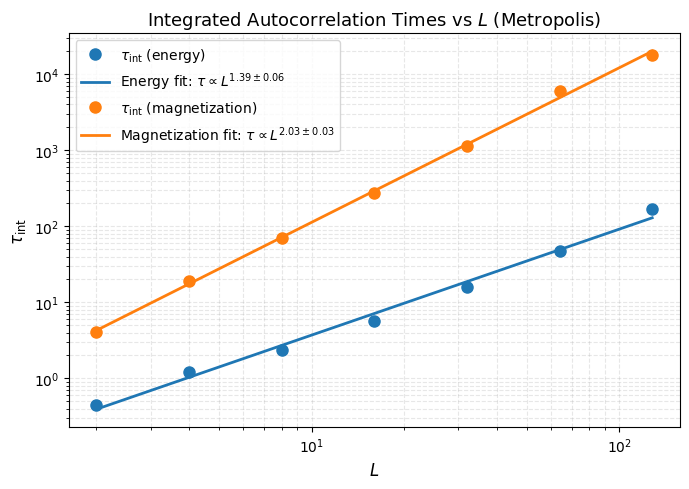

In [49]:
if len(tau_vs_L) < 2:
    print("Not enough valid points to perform the fit.")
else:
    tau_vs_L = np.array(tau_vs_L)
    Ls = tau_vs_L[1, :, 0]
    taus_eng = tau_vs_L[1, :, 1]
    taus_mag = tau_vs_L[0, :, 1]

    logL = np.log(Ls)
    logtau_eng = np.log(taus_eng)
    logtau_mag = np.log(taus_mag)

    slope_eng, intercept_eng, r_value_eng, p_value_eng, std_err_eng = linregress(logL, logtau_eng)
    z_eng = slope_eng
    z_eng_err = std_err_eng
    slope_mag, intercept_mag, r_value_mag, p_value_mag, std_err_mag = linregress(logL, logtau_mag)
    z_mag = slope_mag
    z_mag_err = std_err_mag

    print("\n======================================")
    print(f"Metropolis Dynamic Critical Exponent (Energy): z = {z_eng:.3f} ± {z_eng_err:.3f}")
    print(f"Fit: τ_int = {np.exp(intercept_eng):.3f} * L^{z_eng:.3f}")
    print(f"R² = {r_value_eng**2:.4f}")
    print("======================================\n")

    print("======================================")
    print(f"Metropolis Dynamic Critical Exponent (Magnetization): z = {z_mag:.3f} ± {z_mag_err:.3f}")
    print(f"Fit: τ_int = {np.exp(intercept_mag):.3f} * L^{z_mag:.3f}")
    print(f"R² = {r_value_mag**2:.4f}")
    print("======================================\n")

    plt.close('all')
    plt.figure(figsize=(7,5))
    plt.loglog(Ls, taus_eng, 'o', markersize=8, label=r"$\tau_{\mathrm{int}}$ (energy)", color='C0')
    plt.loglog(Ls, np.exp(intercept_eng) * Ls**z_eng, '-', linewidth=2, 
               label=rf"Energy fit: $\tau \propto L^{{{z_eng:.2f} \pm {z_eng_err:.2f}}}$", color='C0')
    plt.loglog(Ls, taus_mag, 'o', markersize=8, label=r"$\tau_{\mathrm{int}}$ (magnetization)", color='C1')
    plt.loglog(Ls, np.exp(intercept_mag) * Ls**z_mag, '-', linewidth=2, 
               label=rf"Magnetization fit: $\tau \propto L^{{{z_mag:.2f} \pm {z_mag_err:.2f}}}$", color='C1')
    plt.xlabel(r"$L$", fontsize=12)
    plt.ylabel(r"$\tau_{\mathrm{int}}$", fontsize=12)
    plt.title(r"Integrated Autocorrelation Times vs $L$ (Metropolis)", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/metropolis_fss_tau_vs_L.png", dpi=300, bbox_inches='tight')
    plt.show()


## Finite-Size Scaling for Wolff Algorithm

Analyze τ_int(L) at critical temperature β_c for Wolff algorithm to determine dynamical critical exponent z.

In [41]:
# Wolff finite-size scaling at critical temperature
wolff_fss_dir = "data/wolf_temperature_fss"
beta_c = 0.4407
L_list_wolff = [2, 4, 8, 16, 32, 64, 128]

# Load Wolff data for each lattice size at critical temperature
wolff_fss_data = {}
for L in L_list_wolff:
    try:
        data = np.load(f"{wolff_fss_dir}/L_{L}/mag_eng_beta_{beta_c}.npz")
        wolff_fss_data[L] = {
            'energys': data['energys'],
            'magnetizations': data['magnetizations'],
            'numbers_flipped_spins': data['numbers_flipped_spins']
        }
        print(f"Loaded Wolff data for L = {L}: {len(data['energys'])} steps")
    except FileNotFoundError:
        print(f"Wolff data file for L = {L} not found")

print(f"\nLoaded Wolff FSS data for {len(wolff_fss_data)} lattice sizes at β_c = {beta_c}")

Loaded Wolff data for L = 2: 100000 steps
Loaded Wolff data for L = 4: 100000 steps
Loaded Wolff data for L = 8: 100000 steps
Loaded Wolff data for L = 16: 100000 steps
Loaded Wolff data for L = 32: 100000 steps
Loaded Wolff data for L = 64: 100000 steps
Loaded Wolff data for L = 128: 100000 steps

Loaded Wolff FSS data for 7 lattice sizes at β_c = 0.4407


In [42]:
# Compute τ_int for Wolff at each lattice size
wolff_fss_results = {'L': [], 'tau_energy': [], 'tau_mag': []}

print("Computing τ_int for Wolff FSS...")
for L in sorted(wolff_fss_data.keys()):
    data = wolff_fss_data[L]
    print(f"\n===== L = {L} =====")
    
    # Calculate Monte Carlo time scaling factor
    numbers_flipped_spins = data['numbers_flipped_spins']
    delta_t = np.mean(numbers_flipped_spins) / (L * L)
    print(f"  Average Δt per Wolff step: {delta_t:.4f}")
    
    # Energy
    energys = data['energys']
    burn_e, tau_e, ac_e = iterative_burn_and_tau(energys, c_factor=5, min_fraction=0.001, verbose=False)
    
    # Magnetization (use absolute value)
    mags = np.abs(data['magnetizations'])
    burn_m, tau_m, ac_m = iterative_burn_and_tau(mags, c_factor=5, min_fraction=0.001, verbose=False)
    
    if np.isfinite(tau_e) and np.isfinite(tau_m):
        # Convert τ from Wolff steps to Monte Carlo sweeps
        tau_e_mc = tau_e * delta_t
        tau_m_mc = tau_m * delta_t
        
        wolff_fss_results['L'].append(L)
        wolff_fss_results['tau_energy'].append(tau_e_mc)
        wolff_fss_results['tau_mag'].append(tau_m_mc)
        print(f"  Energy: burn={burn_e}, τ_int={tau_e:.3f} Wolff steps = {tau_e_mc:.3f} MC sweeps")
        print(f"  Magnetization: burn={burn_m}, τ_int={tau_m:.3f} Wolff steps = {tau_m_mc:.3f} MC sweeps")
    else:
        print(f"  Skipped (invalid τ)")

print(f"\nWolff FSS: Successfully computed τ_int for {len(wolff_fss_results['L'])} lattice sizes")

Computing τ_int for Wolff FSS...

===== L = 2 =====
  Average Δt per Wolff step: 0.8743
  Energy: burn=2, τ_int=0.593 Wolff steps = 0.518 MC sweeps
  Magnetization: burn=2, τ_int=0.547 Wolff steps = 0.478 MC sweeps

===== L = 4 =====
  Average Δt per Wolff step: 0.7618
  Energy: burn=5, τ_int=1.040 Wolff steps = 0.792 MC sweeps
  Magnetization: burn=5, τ_int=1.015 Wolff steps = 0.773 MC sweeps

===== L = 8 =====
  Average Δt per Wolff step: 0.6487
  Energy: burn=8, τ_int=1.706 Wolff steps = 1.107 MC sweeps
  Magnetization: burn=7, τ_int=1.546 Wolff steps = 1.003 MC sweeps

===== L = 16 =====
  Average Δt per Wolff step: 0.5465
  Energy: burn=5, τ_int=1.040 Wolff steps = 0.792 MC sweeps
  Magnetization: burn=5, τ_int=1.015 Wolff steps = 0.773 MC sweeps

===== L = 8 =====
  Average Δt per Wolff step: 0.6487
  Energy: burn=8, τ_int=1.706 Wolff steps = 1.107 MC sweeps
  Magnetization: burn=7, τ_int=1.546 Wolff steps = 1.003 MC sweeps

===== L = 16 =====
  Average Δt per Wolff step: 0.5465



Wolff Dynamic Critical Exponent (Energy): z = 0.367 ± 0.021
Fit: τ_int = 0.491 * L^0.367
R² = 0.9880

Wolff Dynamic Critical Exponent (Magnetization): z = 0.217 ± 0.035
Fit: τ_int = 0.592 * L^0.217
R² = 0.9019



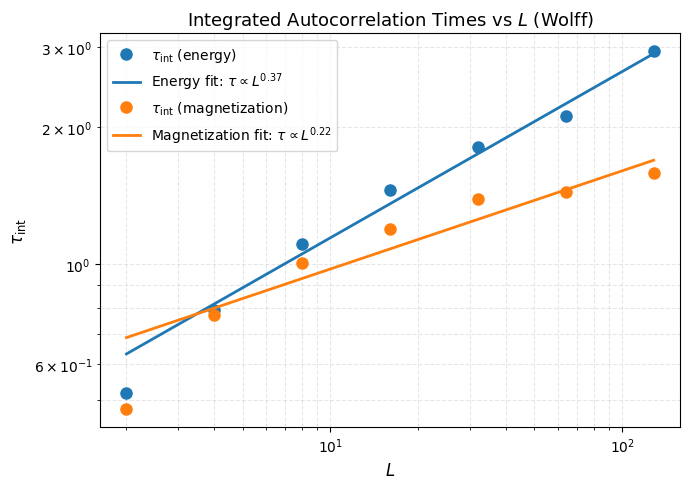

In [48]:
# Fit power law τ_int = A * L^z for Wolff algorithm
from scipy.optimize import curve_fit

def power_law(L, A, z):
    """Power law: τ_int = A * L^z"""
    return A * L**z

# Convert to arrays
L_wolff = np.array(wolff_fss_results['L'])
tau_energy_wolff = np.array(wolff_fss_results['tau_energy'])
tau_mag_wolff = np.array(wolff_fss_results['tau_mag'])

# Fit energy data
popt_e, pcov_e = curve_fit(power_law, L_wolff, tau_energy_wolff, p0=[1.0, 0.3])
A_e, z_e = popt_e
z_e_err = np.sqrt(np.diag(pcov_e))[1]

# Fit magnetization data
popt_m, pcov_m = curve_fit(power_law, L_wolff, tau_mag_wolff, p0=[1.0, 0.3])
A_m, z_m = popt_m
z_m_err = np.sqrt(np.diag(pcov_m))[1]

print("\n======================================")
print(f"Wolff Dynamic Critical Exponent (Energy): z = {z_e:.3f} ± {z_e_err:.3f}")
print(f"Fit: τ_int = {A_e:.3f} * L^{z_e:.3f}")
print(f"R² = {1 - np.sum((tau_energy_wolff - power_law(L_wolff, A_e, z_e))**2) / np.sum((tau_energy_wolff - tau_energy_wolff.mean())**2):.4f}")
print("======================================\n")

print("======================================")
print(f"Wolff Dynamic Critical Exponent (Magnetization): z = {z_m:.3f} ± {z_m_err:.3f}")
print(f"Fit: τ_int = {A_m:.3f} * L^{z_m:.3f}")
print(f"R² = {1 - np.sum((tau_mag_wolff - power_law(L_wolff, A_m, z_m))**2) / np.sum((tau_mag_wolff - tau_mag_wolff.mean())**2):.4f}")
print("======================================\n")

# Plot
L_fit = np.logspace(np.log10(L_wolff.min()), np.log10(L_wolff.max()), 100)

plt.close('all')
plt.figure(figsize=(7, 5))
plt.loglog(L_wolff, tau_energy_wolff, 'o', markersize=8, label=r"$\tau_{\mathrm{int}}$ (energy)", color='C0')
plt.loglog(L_fit, power_law(L_fit, A_e, z_e), '-', linewidth=2, 
           label=rf"Energy fit: $\tau \propto L^{{{z_e:.2f}}}$", color='C0')
plt.loglog(L_wolff, tau_mag_wolff, 'o', markersize=8, label=r"$\tau_{\mathrm{int}}$ (magnetization)", color='C1')
plt.loglog(L_fit, power_law(L_fit, A_m, z_m), '-', linewidth=2, 
           label=rf"Magnetization fit: $\tau \propto L^{{{z_m:.2f}}}$", color='C1')

plt.xlabel(r"$L$", fontsize=12)
plt.ylabel(r"$\tau_{\mathrm{int}}$", fontsize=12)
plt.title(r"Integrated Autocorrelation Times vs $L$ (Wolff)", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig('plots/wolff_fss_tau_vs_L.png', dpi=300, bbox_inches='tight')
plt.show()

## Integrated Autocorrelation Time vs β (Temperature Scan)

Compare τ_int(β) for Metropolis and Wolff algorithms at L=128 across different temperatures.

### Load Wolff data at L=128 for multiple β values

In [31]:
# Load Wolff simulation data at L=128 for temperature scan
wolff_dir = "data/wolf_temperature_fss/L_128"
L = 128

# Read beta list
wolff_beta_list = []
with open("data/wolf_temperature_fss/beta_list.txt", "r") as f:
    for line in f:
        wolff_beta_list.append(float(line.strip()))

print(f"Wolff β values: {wolff_beta_list}")

# Load data for each beta
wolff_data = {}
for beta in wolff_beta_list:
    try:
        data = np.load(f"{wolff_dir}/mag_eng_beta_{beta}.npz")
        wolff_data[beta] = {
            'energys': data['energys'], 
            'magnetizations': data['magnetizations'],
            'numbers_flipped_spins': data['numbers_flipped_spins']
        }
        print(f"Loaded Wolff data for β = {beta}: {len(data['energys'])} steps")
    except FileNotFoundError:
        print(f"Wolff data file for β = {beta} not found")

print(f"\nLoaded Wolff data for {len(wolff_data)} β values")

Wolff β values: [0.1, 0.2, 0.3, 0.4, 0.41, 0.42, 0.43, 0.44, 0.4407, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.6, 1.0, 10.0]
Loaded Wolff data for β = 0.1: 100000 steps
Loaded Wolff data for β = 0.2: 100000 steps
Loaded Wolff data for β = 0.3: 100000 steps
Loaded Wolff data for β = 0.4: 100000 steps
Loaded Wolff data for β = 0.41: 100000 steps
Loaded Wolff data for β = 0.42: 100000 steps
Loaded Wolff data for β = 0.43: 100000 steps
Loaded Wolff data for β = 0.44: 100000 steps
Loaded Wolff data for β = 0.4407: 100000 steps
Loaded Wolff data for β = 0.45: 100000 steps
Loaded Wolff data for β = 0.46: 100000 steps
Loaded Wolff data for β = 0.47: 100000 steps
Loaded Wolff data for β = 0.48: 100000 steps
Loaded Wolff data for β = 0.49: 100000 steps
Loaded Wolff data for β = 0.5: 100000 steps
Loaded Wolff data for β = 0.6: 100000 steps
Loaded Wolff data for β = 1.0: 100000 steps
Loaded Wolff data for β = 10.0: 100000 steps

Loaded Wolff data for 18 β values


### Load Metropolis data at L=128 for multiple β values

In [32]:
# Load Metropolis simulation data at L=128 for temperature scan
metro_dir = "data/Metropolis_Temp_Scan_1_Million_Sweeps/L_128/h_0.0"

# Read beta list
metro_beta_list = []
with open("data/Metropolis_Temp_Scan_1_Million_Sweeps/beta_list.txt", "r") as f:
    for line in f:
        metro_beta_list.append(float(line.strip()))

print(f"Metropolis β values: {metro_beta_list}")

# Load data for each beta
metro_data = {}
for beta in metro_beta_list:
    try:
        data = np.load(f"{metro_dir}/mag_eng_beta_{beta:.4f}.npz")
        metro_data[beta] = {
            'energys': data['energies'],  # Note: 'energies' not 'energys' for Metropolis
            'magnetizations': data['magnetizations']
        }
        print(f"Loaded Metropolis data for β = {beta}: {len(data['energies'])} steps")
    except FileNotFoundError:
        print(f"Metropolis data file for β = {beta} not found")

print(f"\nLoaded Metropolis data for {len(metro_data)} β values")

Metropolis β values: [0.1, 0.2, 0.3, 0.4, 0.41, 0.42, 0.43, 0.44, 0.4407, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.6]
Loaded Metropolis data for β = 0.1: 1000000 steps
Loaded Metropolis data for β = 0.2: 1000000 steps
Loaded Metropolis data for β = 0.3: 1000000 steps
Loaded Metropolis data for β = 0.2: 1000000 steps
Loaded Metropolis data for β = 0.3: 1000000 steps
Loaded Metropolis data for β = 0.4: 1000000 steps
Loaded Metropolis data for β = 0.41: 1000000 steps
Loaded Metropolis data for β = 0.4: 1000000 steps
Loaded Metropolis data for β = 0.41: 1000000 steps
Loaded Metropolis data for β = 0.42: 1000000 steps
Loaded Metropolis data for β = 0.43: 1000000 steps
Loaded Metropolis data for β = 0.42: 1000000 steps
Loaded Metropolis data for β = 0.43: 1000000 steps
Loaded Metropolis data for β = 0.44: 1000000 steps
Loaded Metropolis data for β = 0.4407: 1000000 steps
Loaded Metropolis data for β = 0.45: 1000000 steps
Loaded Metropolis data for β = 0.44: 1000000 steps
Loaded Metropolis data f

### Compute τ_int for Wolff (energy and magnetization)

In [33]:
# Compute integrated autocorrelation time for Wolff data
# Need to convert Wolff steps to Monte Carlo time units for fair comparison with Metropolis
wolff_results = {'beta': [], 'tau_energy': [], 'tau_mag': []}

print("Computing τ_int for Wolff algorithm...")
for beta, data in wolff_data.items():
    print(f"\nβ = {beta}")
    
    # Calculate Monte Carlo time scaling factor
    # Δt = ⟨C⟩/N where C is cluster size, N = L²
    numbers_flipped_spins = data['numbers_flipped_spins']
    delta_t = np.mean(numbers_flipped_spins) / (L * L)
    print(f"  Average Δt per Wolff step: {delta_t:.4f}")
    
    # Energy
    energys = data['energys']
    burn_e, tau_e, ac_e = iterative_burn_and_tau(energys, c_factor=5, min_fraction=0.001, verbose=False)
    
    # Magnetization (use absolute value)
    mags = np.abs(data['magnetizations'])
    burn_m, tau_m, ac_m = iterative_burn_and_tau(mags, c_factor=5, min_fraction=0.001, verbose=False)
    
    if np.isfinite(tau_e) and np.isfinite(tau_m):
        # Convert τ from Wolff steps to Monte Carlo sweeps
        tau_e_mc = tau_e * delta_t
        tau_m_mc = tau_m * delta_t
        
        wolff_results['beta'].append(beta)
        wolff_results['tau_energy'].append(tau_e_mc)
        wolff_results['tau_mag'].append(tau_m_mc)
        print(f"  Energy: burn={burn_e}, τ_int={tau_e:.3f} Wolff steps = {tau_e_mc:.3f} MC sweeps")
        print(f"  Magnetization: burn={burn_m}, τ_int={tau_m:.3f} Wolff steps = {tau_m_mc:.3f} MC sweeps")
    else:
        print(f"  Skipped (invalid τ)")

print(f"\nWolff: Successfully computed τ_int for {len(wolff_results['beta'])} β values")

Computing τ_int for Wolff algorithm...

β = 0.1
  Average Δt per Wolff step: 0.0001
  Energy: burn=11437, τ_int=2171.644 Wolff steps = 0.207 MC sweeps
  Magnetization: burn=5794, τ_int=1158.991 Wolff steps = 0.111 MC sweeps

β = 0.2
  Average Δt per Wolff step: 0.0002
  Energy: burn=11437, τ_int=2171.644 Wolff steps = 0.207 MC sweeps
  Magnetization: burn=5794, τ_int=1158.991 Wolff steps = 0.111 MC sweeps

β = 0.2
  Average Δt per Wolff step: 0.0002
  Energy: burn=11737, τ_int=2191.244 Wolff steps = 0.381 MC sweeps
  Magnetization: burn=2375, τ_int=475.134 Wolff steps = 0.083 MC sweeps

β = 0.3
  Average Δt per Wolff step: 0.0004
  Energy: burn=11737, τ_int=2191.244 Wolff steps = 0.381 MC sweeps
  Magnetization: burn=2375, τ_int=475.134 Wolff steps = 0.083 MC sweeps

β = 0.3
  Average Δt per Wolff step: 0.0004
  Energy: burn=4647, τ_int=929.449 Wolff steps = 0.411 MC sweeps
  Magnetization: burn=1219, τ_int=243.927 Wolff steps = 0.108 MC sweeps

β = 0.4
  Average Δt per Wolff step: 0.0

### Compute τ_int for Metropolis (energy and magnetization)

In [35]:
# Compute integrated autocorrelation time for Metropolis data
# Burn-in times for each beta value
burnin_ls = [1000,1000,1000, 2000,3000,4000, 10_000,100_000,300_000,5_000,5_000,5_000,5_000,10_000,10_000,1_000]
metro_results = {'beta': [], 'tau_energy': [], 'tau_mag': []}

print("Computing τ_int for Metropolis algorithm...")
for i, (beta, data) in enumerate(metro_data.items()):
    print(f"\nβ = {beta}")
    
    # Apply burn-in
    burnin = burnin_ls[i] if i < len(burnin_ls) else 0
    print(f"  Using burn-in: {burnin}")
    
    # Energy (exclude burn-in)
    energys = data['energys'][burnin:]
    burn_e, tau_e, ac_e = iterative_burn_and_tau(energys, c_factor=5, min_fraction=0.001, verbose=False)
    
    # Magnetization (exclude burn-in)
    mags = data['magnetizations'][burnin:]
    burn_m, tau_m, ac_m = iterative_burn_and_tau(mags, c_factor=5, min_fraction=0.001, verbose=False)
    
    if np.isfinite(tau_e) and np.isfinite(tau_m):
        metro_results['beta'].append(beta)
        metro_results['tau_energy'].append(tau_e)
        metro_results['tau_mag'].append(tau_m)

        print(f"  Energy: burn={burn_e}, τ_int={tau_e:.3f}")
        print(f"\nMetropolis: Successfully computed τ_int for {len(metro_results['beta'])} β values")

        print(f"  Magnetization: burn={burn_m}, τ_int={tau_m:.3f}")

    else:        print(f"  Skipped (invalid τ)")

Computing τ_int for Metropolis algorithm...

β = 0.1
  Using burn-in: 1000
  Energy: burn=3, τ_int=0.630

Metropolis: Successfully computed τ_int for 1 β values
  Magnetization: burn=0, τ_int=0.048

β = 0.2
  Using burn-in: 1000
  Energy: burn=3, τ_int=0.630

Metropolis: Successfully computed τ_int for 1 β values
  Magnetization: burn=0, τ_int=0.048

β = 0.2
  Using burn-in: 1000
  Energy: burn=2, τ_int=0.541

Metropolis: Successfully computed τ_int for 2 β values
  Magnetization: burn=3, τ_int=0.741

β = 0.3
  Using burn-in: 1000
  Energy: burn=2, τ_int=0.541

Metropolis: Successfully computed τ_int for 2 β values
  Magnetization: burn=3, τ_int=0.741

β = 0.3
  Using burn-in: 1000
  Energy: burn=3, τ_int=0.778

Metropolis: Successfully computed τ_int for 3 β values
  Magnetization: burn=8, τ_int=1.616

β = 0.4
  Using burn-in: 2000
  Energy: burn=3, τ_int=0.778

Metropolis: Successfully computed τ_int for 3 β values
  Magnetization: burn=8, τ_int=1.616

β = 0.4
  Using burn-in: 2000
 

### Plot τ_int vs β: Comparison of Metropolis and Wolff

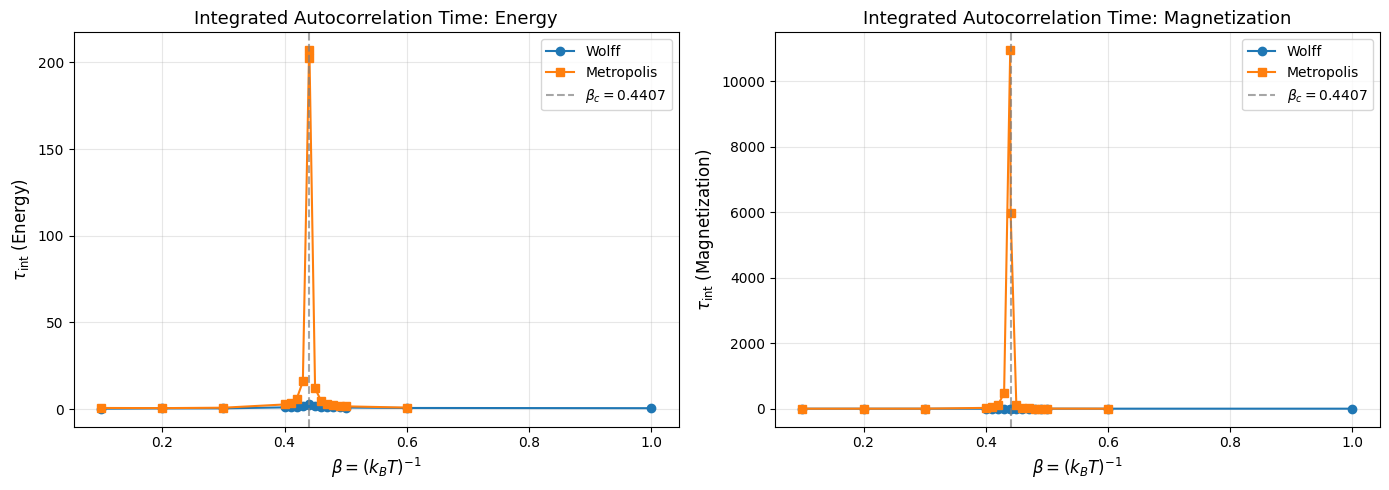


=== Summary: τ_int at critical point (β ≈ 0.4407) ===
Wolff at β=0.4407:
  τ_int(energy) = 2.94
  τ_int(magnetization) = 1.59

Metropolis at β=0.4407:
  τ_int(energy) = 206.97
  τ_int(magnetization) = 5964.37

Speedup factor (Metropolis/Wolff) at critical point:
  Energy: 70.3×
  Magnetization: 3753.2×


In [36]:
# Plot integrated autocorrelation time vs β for both algorithms
beta_c = 0.4407  # Critical temperature

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Energy plot
ax = axes[0]
ax.plot(wolff_results['beta'][:-1], wolff_results['tau_energy'][:-1], 'o-', 
        label='Wolff', markersize=6, linewidth=1.5, color='C0')
ax.plot(metro_results['beta'], metro_results['tau_energy'], 's-', 
        label='Metropolis', markersize=6, linewidth=1.5, color='C1')
ax.axvline(beta_c, linestyle='--', color='gray', alpha=0.7, 
           label=r'$\beta_c = 0.4407$')
ax.set_xlabel(r'$\beta = (k_B T)^{-1}$', fontsize=12)
ax.set_ylabel(r'$\tau_{\mathrm{int}}$ (Energy)', fontsize=12)
ax.set_title('Integrated Autocorrelation Time: Energy', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Magnetization plot
ax = axes[1]
ax.plot(wolff_results['beta'][:-1], wolff_results['tau_mag'][:-1], 'o-', 
        label='Wolff', markersize=6, linewidth=1.5, color='C0')
ax.plot(metro_results['beta'], metro_results['tau_mag'], 's-', 
        label='Metropolis', markersize=6, linewidth=1.5, color='C1')
ax.axvline(beta_c, linestyle='--', color='gray', alpha=0.7, 
           label=r'$\beta_c = 0.4407$')
ax.set_xlabel(r'$\beta = (k_B T)^{-1}$', fontsize=12)
ax.set_ylabel(r'$\tau_{\mathrm{int}}$ (Magnetization)', fontsize=12)
ax.set_title('Integrated Autocorrelation Time: Magnetization', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/tau_int_vs_beta_comparison_L128.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Summary: τ_int at critical point (β ≈ 0.4407) ===")
idx_wolff = np.argmin(np.abs(np.array(wolff_results['beta']) - beta_c))
idx_metro = np.argmin(np.abs(np.array(metro_results['beta']) - beta_c))

print(f"Wolff at β={wolff_results['beta'][idx_wolff]:.4f}:")
print(f"  τ_int(energy) = {wolff_results['tau_energy'][idx_wolff]:.2f}")
print(f"  τ_int(magnetization) = {wolff_results['tau_mag'][idx_wolff]:.2f}")

print(f"\nMetropolis at β={metro_results['beta'][idx_metro]:.4f}:")
print(f"  τ_int(energy) = {metro_results['tau_energy'][idx_metro]:.2f}")
print(f"  τ_int(magnetization) = {metro_results['tau_mag'][idx_metro]:.2f}")

ratio_e = metro_results['tau_energy'][idx_metro] / wolff_results['tau_energy'][idx_wolff]
ratio_m = metro_results['tau_mag'][idx_metro] / wolff_results['tau_mag'][idx_wolff]
print(f"\nSpeedup factor (Metropolis/Wolff) at critical point:")
print(f"  Energy: {ratio_e:.1f}×")
print(f"  Magnetization: {ratio_m:.1f}×")

### Log-scale plot to highlight differences near critical point

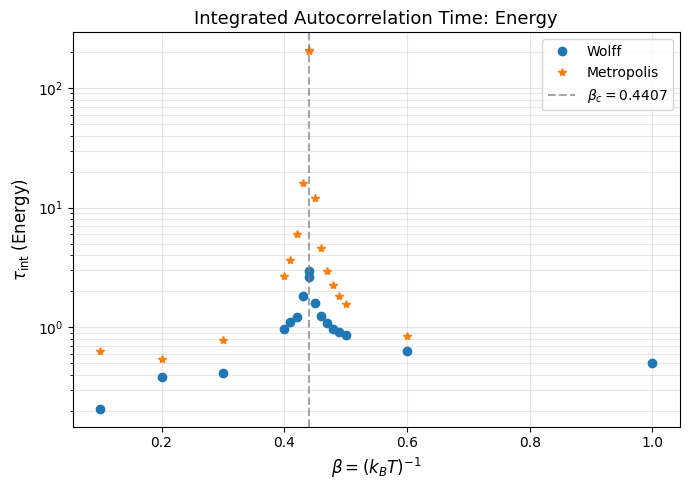

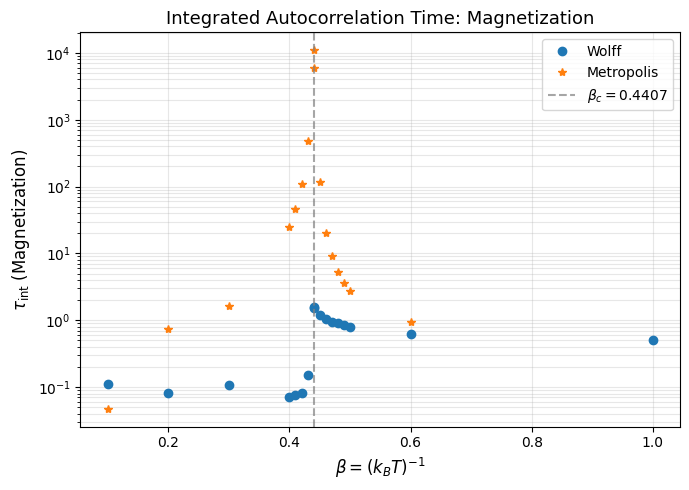

In [40]:
# Log-scale plots to better show the critical slowing down

# Energy plot (log scale)
plt.figure(figsize=(7, 5))
plt.semilogy(wolff_results['beta'][:-1], wolff_results['tau_energy'][:-1], 'o', 
            label='Wolff', markersize=6, linewidth=1.5, color='C0')
plt.semilogy(metro_results['beta'], metro_results['tau_energy'], '*', 
            label='Metropolis', markersize=6, linewidth=1.5, color='C1')
plt.axvline(beta_c, linestyle='--', color='gray', alpha=0.7, 
           label=r'$\beta_c = 0.4407$')
plt.xlabel(r'$\beta = (k_B T)^{-1}$', fontsize=12)
plt.ylabel(r'$\tau_{\mathrm{int}}$ (Energy)', fontsize=12)
plt.title('Integrated Autocorrelation Time: Energy', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/tau_int_vs_beta_energy_L128_log.png', dpi=300, bbox_inches='tight')
plt.show()

# Magnetization plot (log scale)
plt.figure(figsize=(7, 5))
plt.semilogy(wolff_results['beta'][:-1], wolff_results['tau_mag'][:-1], 'o', 
            label='Wolff', markersize=6, linewidth=1.5, color='C0')
plt.semilogy(metro_results['beta'], metro_results['tau_mag'], '*', 
            label='Metropolis', markersize=6, linewidth=1.5, color='C1')
plt.axvline(beta_c, linestyle='--', color='gray', alpha=0.7, 
           label=r'$\beta_c = 0.4407$')
plt.xlabel(r'$\beta = (k_B T)^{-1}$', fontsize=12)
plt.ylabel(r'$\tau_{\mathrm{int}}$ (Magnetization)', fontsize=12)
plt.title('Integrated Autocorrelation Time: Magnetization', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('plots/tau_int_vs_beta_magnetization_L128_log.png', dpi=300, bbox_inches='tight')
plt.show()